LOAD DATA

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import sys
from scipy.stats import norm

c:\Users\Private\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Private\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Private\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/f

In [2]:
data = pd.read_excel(r"C:\Users\Private\Downloads\SACEMA\volume22 landmarks nuhr_jwh_AIMS_VERSION.xlsx", sheet_name="Sheet1")
data

,n,vpn,cd,cm,cy,md,g,s,c,wlmm,...,r_y10,r_x11,r_y11,dis_R,Unnamed: 69,R_x0,R_y0,R_xi,R_yi,RIGHT wing
0,1,22077901,1,August,96,Odour-baited trap,Gp,2,2.0,7.61,...,487.285828,956.266357,387.787781,1098.062710,NaN,598.397113,515.828214,6.398100e+06,3.268734e+06,3109.153262
1,2,22077902,1,August,96,Odour-baited trap,Gp,2,1.0,7.61,...,518.133789,883.474731,395.640503,1091.836122,NaN,546.094477,550.684473,5.455975e+06,3.766106e+06,3036.787885
2,3,22077903,1,August,96,Odour-baited trap,Gp,2,7.0,7.32,...,545.683350,868.167419,421.171875,1056.701373,NaN,539.616868,581.565199,5.233729e+06,4.167086e+06,3066.074901
3,4,22077904,1,August,96,Odour-baited trap,Gp,2,7.0,7.23,...,539.527710,847.430664,434.247406,1050.264875,NaN,518.701957,568.403576,5.040212e+06,3.926600e+06,2994.463653
4,5,22077905,1,August,96,Odour-baited trap,Gp,2,1.0,7.71,...,509.326538,916.870667,387.414612,1119.489692,NaN,558.962691,538.461581,5.790110e+06,3.602098e+06,3064.670909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7438,7439,22115516,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,535.467346,879.874756,415.528137,990.340681,NaN,573.837060,556.457744,5.540442e+06,3.787833e+06,3054.222389
7439,7440,22115517,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,549.529846,842.752197,435.414246,993.652461,NaN,526.281480,576.302585,4.929847e+06,4.036707e+06,2994.420489
7440,7441,22115518,24,February,97,Odour-baited trap,Gp,1,NaN,6.84,...,500.062622,892.186035,388.423645,991.759396,NaN,579.887391,527.844388,5.659194e+06,3.426293e+06,3014.214062
7441,7442,22115519,24,February,97,Odour-baited trap,Gp,2,6.0,6.75,...,522.516968,833.267700,412.146088,966.412864,NaN,528.234014,557.854156,4.857911e+06,3.807530e+06,2943.712067


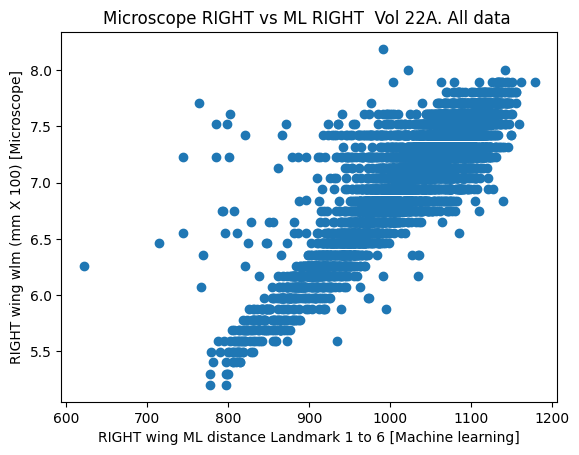

In [3]:
plt.scatter(data["dis_R"], data["wlmm"])
plt.xlabel("RIGHT wing ML distance Landmark 1 to 6 [Machine learning]")
plt.ylabel("RIGHT wing wlm (mm X 100) [Microscope]")
plt.title("Microscope RIGHT vs ML RIGHT  Vol 22A. All data ")
plt.show()



In [4]:
print(data[["dis_R", "wlmm"]].isna().sum())


dis_R    7
wlmm     0
dtype: int64


In [5]:
data = data.dropna(subset=["dis_R"])


In [6]:
data[data["dis_R"].isna()]


,n,vpn,cd,cm,cy,md,g,s,c,wlmm,...,r_y10,r_x11,r_y11,dis_R,Unnamed: 69,R_x0,R_y0,R_xi,R_yi,RIGHT wing


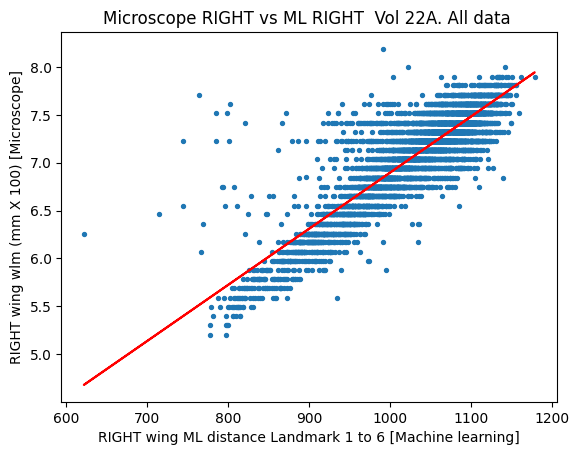

Slope: 0.0058752294786074116
Intercept: 1.0229669928947436


In [7]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X = data[["dis_R"]]   # must be 2D
y = data["wlmm"]

model = LinearRegression()
model.fit(X, y)

y_fit = model.predict(X)

plt.figure()
plt.scatter(X, y, s=8)
plt.plot(X, y_fit, color= "red")
plt.xlabel("RIGHT wing ML distance Landmark 1 to 6 [Machine learning]")
plt.ylabel("RIGHT wing wlm (mm X 100) [Microscope]")
plt.title("Microscope RIGHT vs ML RIGHT  Vol 22A. All data ")
plt.show()
Slope= model.coef_[0]
Intercept= model.intercept_
print("Slope:", Slope)
print("Intercept:", Intercept)


CALCULATE THE ERROR

In [8]:
data["Ml_cal"]= Slope*data["dis_R"] + Intercept

C:\Users\Private\AppData\Local\Temp\ipykernel_9056\878709459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Ml_cal"]= Slope*data["dis_R"] + Intercept


In [9]:
data

,n,vpn,cd,cm,cy,md,g,s,c,wlmm,...,r_x11,r_y11,dis_R,Unnamed: 69,R_x0,R_y0,R_xi,R_yi,RIGHT wing,Ml_cal
0,1,22077901,1,August,96,Odour-baited trap,Gp,2,2.0,7.61,...,956.266357,387.787781,1098.062710,NaN,598.397113,515.828214,6.398100e+06,3.268734e+06,3109.153262,7.474337
1,2,22077902,1,August,96,Odour-baited trap,Gp,2,1.0,7.61,...,883.474731,395.640503,1091.836122,NaN,546.094477,550.684473,5.455975e+06,3.766106e+06,3036.787885,7.437755
2,3,22077903,1,August,96,Odour-baited trap,Gp,2,7.0,7.32,...,868.167419,421.171875,1056.701373,NaN,539.616868,581.565199,5.233729e+06,4.167086e+06,3066.074901,7.231330
3,4,22077904,1,August,96,Odour-baited trap,Gp,2,7.0,7.23,...,847.430664,434.247406,1050.264875,NaN,518.701957,568.403576,5.040212e+06,3.926600e+06,2994.463653,7.193514
4,5,22077905,1,August,96,Odour-baited trap,Gp,2,1.0,7.71,...,916.870667,387.414612,1119.489692,NaN,558.962691,538.461581,5.790110e+06,3.602098e+06,3064.670909,7.600226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7438,7439,22115516,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,879.874756,415.528137,990.340681,NaN,573.837060,556.457744,5.540442e+06,3.787833e+06,3054.222389,6.841446
7439,7440,22115517,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,842.752197,435.414246,993.652461,NaN,526.281480,576.302585,4.929847e+06,4.036707e+06,2994.420489,6.860903
7440,7441,22115518,24,February,97,Odour-baited trap,Gp,1,NaN,6.84,...,892.186035,388.423645,991.759396,NaN,579.887391,527.844388,5.659194e+06,3.426293e+06,3014.214062,6.849781
7441,7442,22115519,24,February,97,Odour-baited trap,Gp,2,6.0,6.75,...,833.267700,412.146088,966.412864,NaN,528.234014,557.854156,4.857911e+06,3.807530e+06,2943.712067,6.700864


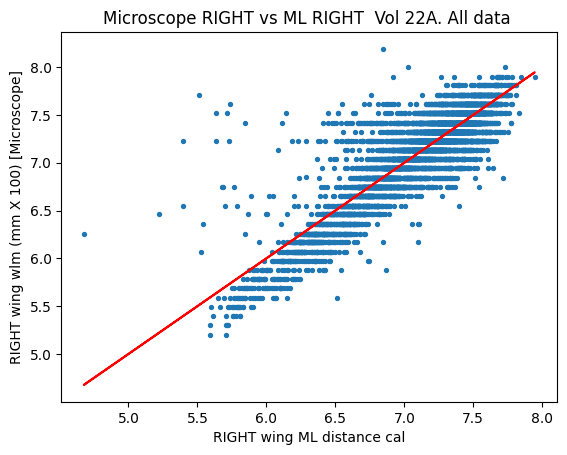

Slope: 0.9999999999999996
Intercept: 3.552713678800501e-15


In [10]:
x = data[["Ml_cal"]]   # must be 2D
Y = data["wlmm"]

model2 = LinearRegression()
model2.fit(x, Y)

Y_fit = model2.predict(x)

plt.figure()
plt.scatter(x, Y, s=8)
plt.plot(x, Y_fit, color= "red")
plt.xlabel("RIGHT wing ML distance cal")
plt.ylabel("RIGHT wing wlm (mm X 100) [Microscope]")
plt.title("Microscope RIGHT vs ML RIGHT  Vol 22A. All data ")
plt.show()
slope= model2.coef_[0]
intercept= model2.intercept_
print("Slope:", slope)
print("Intercept:", intercept)


In [11]:
data["Residual"]= (data["Ml_cal"]-data["wlmm"])

C:\Users\Private\AppData\Local\Temp\ipykernel_9056\731246135.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Residual"]= (data["Ml_cal"]-data["wlmm"])


In [12]:
data

,n,vpn,cd,cm,cy,md,g,s,c,wlmm,...,r_y11,dis_R,Unnamed: 69,R_x0,R_y0,R_xi,R_yi,RIGHT wing,Ml_cal,Residual
0,1,22077901,1,August,96,Odour-baited trap,Gp,2,2.0,7.61,...,387.787781,1098.062710,NaN,598.397113,515.828214,6.398100e+06,3.268734e+06,3109.153262,7.474337,-0.135663
1,2,22077902,1,August,96,Odour-baited trap,Gp,2,1.0,7.61,...,395.640503,1091.836122,NaN,546.094477,550.684473,5.455975e+06,3.766106e+06,3036.787885,7.437755,-0.172245
2,3,22077903,1,August,96,Odour-baited trap,Gp,2,7.0,7.32,...,421.171875,1056.701373,NaN,539.616868,581.565199,5.233729e+06,4.167086e+06,3066.074901,7.231330,-0.088670
3,4,22077904,1,August,96,Odour-baited trap,Gp,2,7.0,7.23,...,434.247406,1050.264875,NaN,518.701957,568.403576,5.040212e+06,3.926600e+06,2994.463653,7.193514,-0.036486
4,5,22077905,1,August,96,Odour-baited trap,Gp,2,1.0,7.71,...,387.414612,1119.489692,NaN,558.962691,538.461581,5.790110e+06,3.602098e+06,3064.670909,7.600226,-0.109774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7438,7439,22115516,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,415.528137,990.340681,NaN,573.837060,556.457744,5.540442e+06,3.787833e+06,3054.222389,6.841446,-0.098554
7439,7440,22115517,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,435.414246,993.652461,NaN,526.281480,576.302585,4.929847e+06,4.036707e+06,2994.420489,6.860903,-0.079097
7440,7441,22115518,24,February,97,Odour-baited trap,Gp,1,NaN,6.84,...,388.423645,991.759396,NaN,579.887391,527.844388,5.659194e+06,3.426293e+06,3014.214062,6.849781,0.009781
7441,7442,22115519,24,February,97,Odour-baited trap,Gp,2,6.0,6.75,...,412.146088,966.412864,NaN,528.234014,557.854156,4.857911e+06,3.807530e+06,2943.712067,6.700864,-0.049136


In [13]:
data["|R|"]= np.absolute(data['Residual'])
data["R^2"]= (data["Residual"])**2

C:\Users\Private\AppData\Local\Temp\ipykernel_9056\238502727.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["|R|"]= np.absolute(data['Residual'])
C:\Users\Private\AppData\Local\Temp\ipykernel_9056\238502727.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["R^2"]= (data["Residual"])**2


In [14]:
summary = data["|R|"].describe()
print(summary)


count    7436.000000
mean        0.151340
std         0.152006
min         0.000016
25%         0.051342
50%         0.111111
75%         0.203494
max         2.196628
Name: |R|, dtype: float64


In [15]:
data

,n,vpn,cd,cm,cy,md,g,s,c,wlmm,...,Unnamed: 69,R_x0,R_y0,R_xi,R_yi,RIGHT wing,Ml_cal,Residual,|R|,R^2
0,1,22077901,1,August,96,Odour-baited trap,Gp,2,2.0,7.61,...,NaN,598.397113,515.828214,6.398100e+06,3.268734e+06,3109.153262,7.474337,-0.135663,0.135663,0.018404
1,2,22077902,1,August,96,Odour-baited trap,Gp,2,1.0,7.61,...,NaN,546.094477,550.684473,5.455975e+06,3.766106e+06,3036.787885,7.437755,-0.172245,0.172245,0.029668
2,3,22077903,1,August,96,Odour-baited trap,Gp,2,7.0,7.32,...,NaN,539.616868,581.565199,5.233729e+06,4.167086e+06,3066.074901,7.231330,-0.088670,0.088670,0.007862
3,4,22077904,1,August,96,Odour-baited trap,Gp,2,7.0,7.23,...,NaN,518.701957,568.403576,5.040212e+06,3.926600e+06,2994.463653,7.193514,-0.036486,0.036486,0.001331
4,5,22077905,1,August,96,Odour-baited trap,Gp,2,1.0,7.71,...,NaN,558.962691,538.461581,5.790110e+06,3.602098e+06,3064.670909,7.600226,-0.109774,0.109774,0.012050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7438,7439,22115516,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,NaN,573.837060,556.457744,5.540442e+06,3.787833e+06,3054.222389,6.841446,-0.098554,0.098554,0.009713
7439,7440,22115517,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,NaN,526.281480,576.302585,4.929847e+06,4.036707e+06,2994.420489,6.860903,-0.079097,0.079097,0.006256
7440,7441,22115518,24,February,97,Odour-baited trap,Gp,1,NaN,6.84,...,NaN,579.887391,527.844388,5.659194e+06,3.426293e+06,3014.214062,6.849781,0.009781,0.009781,0.000096
7441,7442,22115519,24,February,97,Odour-baited trap,Gp,2,6.0,6.75,...,NaN,528.234014,557.854156,4.857911e+06,3.807530e+06,2943.712067,6.700864,-0.049136,0.049136,0.002414


In [16]:
def highlight_row(row):
    
    r = abs(row["Residual"])
    
    if r > 1 :
        color = "background-color: red"
    if r > 0.5:
        color = "background-color: magenta"
    elif r > 0.1:
        color = "background-color: orange"
    else:
        color = "background-color: green"
    
    return [color if col in ["vpn", "|R|"] else "" for col in row.index]


In [17]:

# data.style.apply(highlight_row, axis=1)



In [18]:
%pip install pandas openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
output_excel = "wing_analysis_results.xlsx"
data.to_excel(output_excel, index=False)  # index=False removes the DataFrame index column
print(f"Results saved to {output_excel}")


Results saved to wing_analysis_results.xlsx


DAMAGE DETECTION

In [20]:
%pip install opencv-python


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import cv2 # for image processing
import numpy as np
import matplotlib.pyplot as plt


(np.float64(-0.5), np.float64(79.5), np.float64(59.5), np.float64(-0.5))

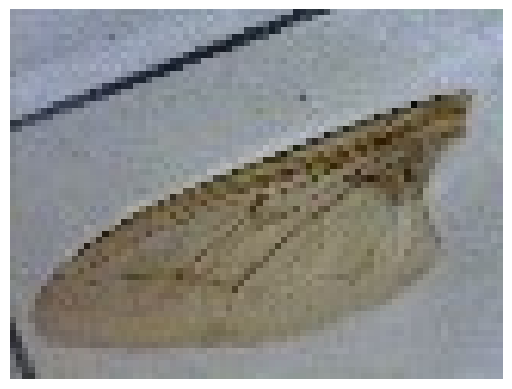

In [22]:
#HOW TO IMPORT A PICTURE
img = cv2.imread(r"C:\Users\Private\Downloads\A037 - 20161216_173458.jpg")   # <-- your image path
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")


TESTING 1 CASE

In [23]:
# import cv2
# import numpy as np

# # Load baseline wing (right wing)
# baseline_path = r"C:\Users\Private\Downloads\A036 - 20161216_173452.jpg"
# baseline = cv2.imread(baseline_path)
# baseline_gray = cv2.cvtColor(baseline, cv2.COLOR_BGR2GRAY)
# baseline_blur = cv2.GaussianBlur(baseline_gray, (5,5), 0) # it maes the noise disappear
# baseline_edges = cv2.Canny(baseline_blur, 50, 150) # turns images into a sketch
# baseline_contours, _ = cv2.findContours(baseline_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# # Use the largest contour as the wing
# baseline_contour = max(baseline_contours, key=cv2.contourArea)
# cv2.imshow('Baseline Edges (Sketch)', baseline_edges)


In [24]:
# # Load test wing
# test_path = r"C:\Users\Private\Downloads\A020 - 20161216_173348.jpg"
# test = cv2.imread(test_path)
# test_gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)
# test_blur = cv2.GaussianBlur(test_gray, (5,5), 0)
# test_edges = cv2.Canny(test_blur, 50, 150)
# test_contours, _ = cv2.findContours(test_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# # Use largest contour
# test_contour = max(test_contours, key=cv2.contourArea)

# # Compare shapes
# similarity = cv2.matchShapes(baseline_contour, test_contour, cv2.CONTOURS_MATCH_I1, 0)
# print(f"Shape similarity score: {similarity:.4f}")

# # Threshold to flag damage
# threshold = 0.8  # adjust based on experimentation
# if similarity > threshold:
#     print("Test wing may have missing ends or damage")
# else:
#     print("Test wing looks complete")


TESTING MANY PICTURES

In [25]:
import cv2
import numpy as np
import os
import pandas as pd
import re
import zipfile


EXTRACT RIGHT WING PICTURES

In [26]:
# import zipfile
# import os
# import re
# import shutil

# #SETTINGS 
# zip_path = r"C:\Users\Private\Downloads\V22-20260210T125413Z-3-002.zip"                # your zip file
# extract_temp = "temp_extract2"            # temp extraction folder
# output_folder = "even_images_only2"       # final output folder

# image_extensions = (".jpg", ".jpeg", ".png", ".tiff", ".webp")


# # Create folders
# os.makedirs(extract_temp, exist_ok=True)
# os.makedirs(output_folder, exist_ok=True)

# # Extract zip 
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_temp)

# print("ZIP extracted")

# copy_count = 0

# #  Recursively scan folders 
# for root, dirs, files in os.walk(extract_temp):
#     for file in files:
#         file_lower = file.lower()

#         # Only images
#         if file_lower.endswith(image_extensions):

#             # Extract numbers from filename
#             numbers = re.findall(r'\d+', file)


#             if numbers:
#                 code = int(numbers[0])  

#                 # Check even code (right wings)
#                 if code % 2 == 0:
#                     src_path = os.path.join(root, file)
#                     dst_path = os.path.join(output_folder, file)

#                     shutil.copy(src_path, dst_path)
#                     copy_count +=1
#                     print(f"Copied: {file}")

# print("\nDone!")
# print("Even-coded images saved in:", output_folder)
# print(f" Total file copied:{copy_count}")

NEW DATA TABLE

In [71]:
df = pd.read_excel(r"C:\Users\Private\Downloads\WQU\wing_analysis_results(AutoRecovered).xlsx", sheet_name="Sheet1")
df

,n,vpn,cd,cm,cy,md,g,s,c,wlmm,...,R_yi,RIGHT wing,Ml_cal,Residual,|R|,R^2,Possible reason,Notes,Unnamed: 81,vpn.1
0,1,22077901,1,August,96,Odour-baited trap,Gp,2,2.0,7.61,...,3.268734e+06,3109.153262,7.474337,-0.135663,0.135663,0.018404,NO DAMAGE TO RIGHT WING,NaN,NaN,22077901
1,2,22077902,1,August,96,Odour-baited trap,Gp,2,1.0,7.61,...,3.766106e+06,3036.787885,7.437755,-0.172245,0.172245,0.029668,NO DAMAGE TO RIGHT WING,NaN,NaN,22077902
2,3,22077903,1,August,96,Odour-baited trap,Gp,2,7.0,7.32,...,4.167086e+06,3066.074901,7.231330,-0.088670,0.088670,0.007862,NO DAMAGE TO RIGHT WING,NaN,NaN,22077903
3,4,22077904,1,August,96,Odour-baited trap,Gp,2,7.0,7.23,...,3.926600e+06,2994.463653,7.193514,-0.036486,0.036486,0.001331,NO DAMAGE TO RIGHT WING,NaN,NaN,22077904
4,5,22077905,1,August,96,Odour-baited trap,Gp,2,1.0,7.71,...,3.602098e+06,3064.670909,7.600226,-0.109774,0.109774,0.012050,NO DAMAGE TO RIGHT WING,NaN,NaN,22077905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7431,7439,22115516,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,3.787833e+06,3054.222389,6.841446,-0.098554,0.098554,0.009713,NO DAMAGE TO RIGHT WING,NaN,NaN,22115516
7432,7440,22115517,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,4.036707e+06,2994.420489,6.860903,-0.079097,0.079097,0.006256,NO DAMAGE TO RIGHT WING,NaN,NaN,22115517
7433,7441,22115518,24,February,97,Odour-baited trap,Gp,1,NaN,6.84,...,3.426293e+06,3014.214062,6.849781,0.009781,0.009781,0.000096,NO DAMAGE TO RIGHT WING,NaN,NaN,22115518
7434,7442,22115519,24,February,97,Odour-baited trap,Gp,2,6.0,6.75,...,3.807530e+06,2943.712067,6.700864,-0.049136,0.049136,0.002414,NO DAMAGE TO RIGHT WING,NaN,NaN,22115519


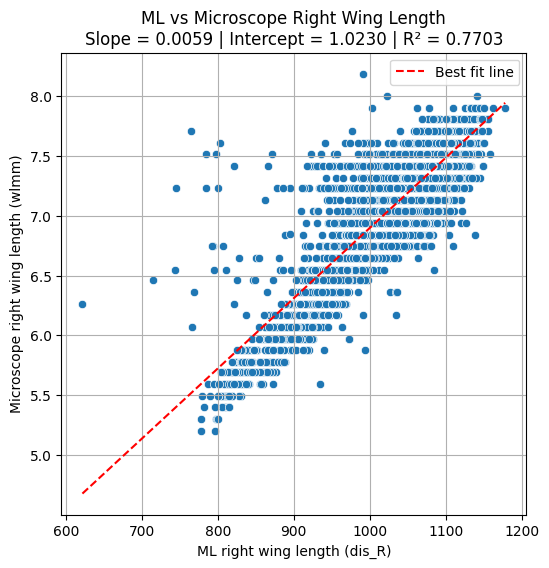

Slope: 0.0059
Intercept: 1.0230
R: 0.8776
R²: 0.7703
P-value: 0.0000e+00
Std error: 0.0000


In [121]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.figure(figsize=(6,6))

# Scatter
sns.scatterplot(x="dis_R", y="wlmm", data=data)

# Line of best fit (linear regression)
x = data["dis_R"]
y = data["wlmm"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_vals = np.array([x.min(), x.max()])
y_fit = intercept + slope * x_vals

plt.plot(x_vals, y_fit, linestyle="--", color="red", label="Best fit line")

# Labels
plt.xlabel("ML right wing length (dis_R)")
plt.ylabel("Microscope right wing length (wlmm)")

# ---- Title with statistics ----
r2 = r_value**2
plt.title(
    f"ML vs Microscope Right Wing Length\n"
    f"Slope = {slope:.4f} | Intercept = {intercept:.4f} | R² = {r2:.4f}"
)

plt.legend()
plt.grid(True)
plt.show()

# Optional console output
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R: {r_value:.4f}")
print(f"R²: {r2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Std error: {std_err:.4f}")


Original size: 7436
Filtered size: 7054


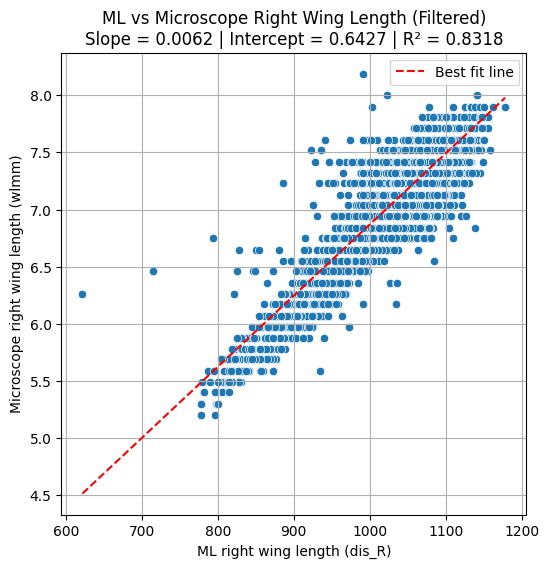


--- Regression after filtering ---
Slope: 0.0062
Intercept: 0.6427
R: 0.9120
R²: 0.8318
P-value: 0.0000e+00
Std error: 0.0000


In [123]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# -----------------------------
# 1. FILTER THE DATA
# -----------------------------
filtered_data = df[
    ~df["Possible reason"].str.lower().isin([
        "missing right wing",
        "damaged right wing",
        "misslabelled"
    ])
].copy()

print(f"Original size: {len(data)}")
print(f"Filtered size: {len(filtered_data)}")

# -----------------------------
# 2. REGRESSION ON CLEAN DATA
# -----------------------------
x = filtered_data["dis_R"]
y = filtered_data["wlmm"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r2 = r_value**2

# -----------------------------
# 3. PLOT
# -----------------------------
plt.figure(figsize=(6,6))

sns.scatterplot(x=x, y=y)

x_vals = np.array([x.min(), x.max()])
y_fit = intercept + slope * x_vals

plt.plot(x_vals, y_fit, linestyle="--", color="red", label="Best fit line")

plt.xlabel("ML right wing length (dis_R)")
plt.ylabel("Microscope right wing length (wlmm)")

plt.title(
    f"ML vs Microscope Right Wing Length (Filtered)\n"
    f"Slope = {slope:.4f} | Intercept = {intercept:.4f} | R² = {r2:.4f}"
)

plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 4. PRINT STATS
# -----------------------------
print("\n--- Regression after filtering ---")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R: {r_value:.4f}")
print(f"R²: {r2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Std error: {std_err:.4f}")


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='dis_R', ylabel='dis_l (wlm)'>

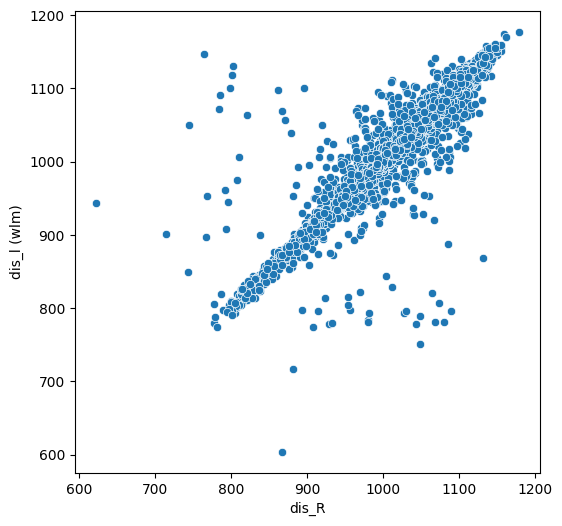

In [29]:
plt.figure(figsize=(6,6))
sns.scatterplot(x="dis_R", y="dis_l (wlm)", data=df)

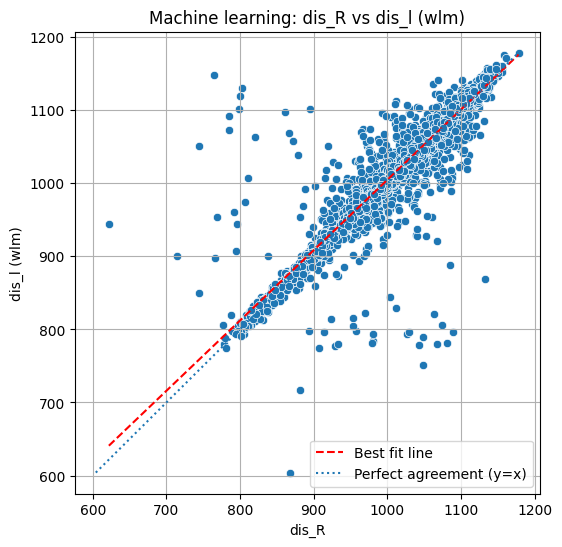

Slope: 0.9609
Intercept: 43.2791
R: 0.9403
R²: 0.8842
P-value: 0.0000e+00
Std error: 0.0040


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.figure(figsize=(6,6))

# Scatter
sns.scatterplot(x="dis_R", y="dis_l (wlm)", data=df)

# Line of best fit (linear regression)
x = df["dis_R"]
y = df["dis_l (wlm)"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_vals = np.array([x.min(), x.max()])
y_fit = intercept + slope * x_vals

plt.plot(x_vals, y_fit, linestyle="--", color="red", label="Best fit line")

# Identity line (perfect agreement y = x)
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle=":", label="Perfect agreement (y=x)")

# Labels
plt.xlabel("dis_R")
plt.ylabel("dis_l (wlm)")
plt.title("Machine learning: dis_R vs dis_l (wlm)")
plt.legend()
plt.grid(True)

plt.show()

# Print stats
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R: {r_value:.4f}")
print(f"R²: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Std error: {std_err:.4f}")


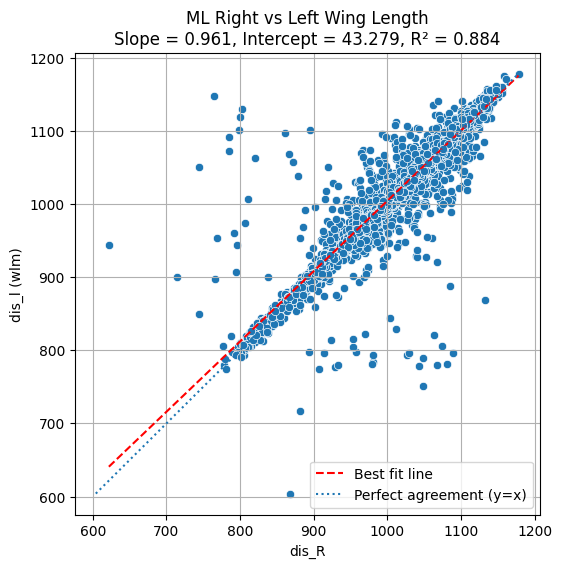

Slope: 0.9609
Intercept: 43.2791
R: 0.9403
R²: 0.8842
P-value: 0.0000e+00
Std error: 0.0040


In [124]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.figure(figsize=(6,6))

# Scatter
sns.scatterplot(x="dis_R", y="dis_l (wlm)", data=df)

# Line of best fit (linear regression)
x = df["dis_R"]
y = df["dis_l (wlm)"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r2 = r_value**2  # compute R²

x_vals = np.array([x.min(), x.max()])
y_fit = intercept + slope * x_vals

plt.plot(x_vals, y_fit, linestyle="--", color="red", label="Best fit line")

# Identity line (perfect agreement y = x)
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle=":", label="Perfect agreement (y=x)")

# Labels
plt.xlabel("dis_R")
plt.ylabel("dis_l (wlm)")

# Title with slope, intercept, and R²
plt.title(f"ML Right vs Left Wing Length\nSlope = {slope:.3f}, Intercept = {intercept:.3f}, R² = {r2:.3f}")

plt.legend()
plt.grid(True)
plt.show()

# Print stats to console
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R: {r_value:.4f}")
print(f"R²: {r2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Std error: {std_err:.4f}")


Original dataset size: 7436
Filtered dataset size: 7007


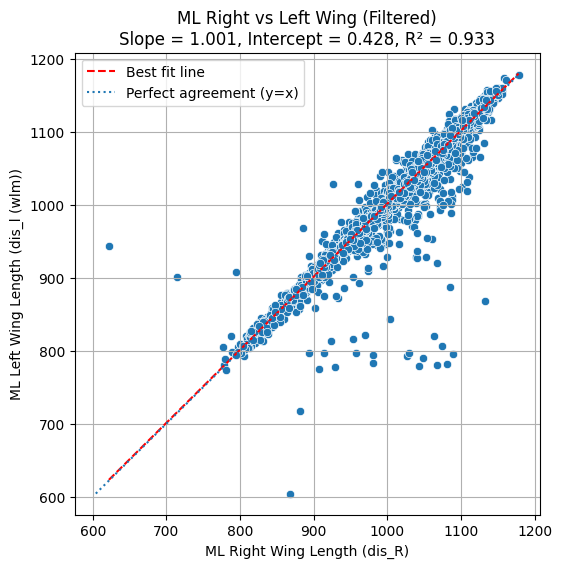


--- Regression after filtering ---
Slope: 1.0010
Intercept: 0.4282
R: 0.9661
R²: 0.9334
P-value: 0.0000e+00
Std error: 0.0032


In [126]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# -----------------------------
# 1. FILTER DATA
# -----------------------------
# Adjust column name if needed
# Remove wings with any invalid reason: missing, damaged, mislabeled
invalid_keywords = ["missing right wing", "damaged right wing", "misslabelled", "little damage"]
filtered_df = df[
    ~df["Possible reason"].str.lower().str.contains("|".join(invalid_keywords), na=False)
].copy()

print(f"Original dataset size: {len(df)}")
print(f"Filtered dataset size: {len(filtered_df)}")

# -----------------------------
# 2. REGRESSION
# -----------------------------
x = filtered_df["dis_R"]
y = filtered_df["dis_l (wlm)"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r2 = r_value**2

# -----------------------------
# 3. PLOT
# -----------------------------
plt.figure(figsize=(6,6))

sns.scatterplot(x=x, y=y)

# Best fit line
x_vals = np.array([x.min(), x.max()])
y_fit = intercept + slope * x_vals
plt.plot(x_vals, y_fit, linestyle="--", color="red", label="Best fit line")

# Identity line (perfect agreement y=x)
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle=":", label="Perfect agreement (y=x)")

# Labels and title
plt.xlabel("ML Right Wing Length (dis_R)")
plt.ylabel("ML Left Wing Length (dis_l (wlm))")
plt.title(f"ML Right vs Left Wing (Filtered)\nSlope = {slope:.3f}, Intercept = {intercept:.3f}, R² = {r2:.3f}")

plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 4. PRINT STATS
# -----------------------------
print("\n--- Regression after filtering ---")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R: {r_value:.4f}")
print(f"R²: {r2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Std error: {std_err:.4f}")


In [127]:
import numpy as np
from scipy import stats

# -----------------------------
# 1. FILTER DATA (already filtered)
# -----------------------------
invalid_keywords = ["missing right wing", "damaged right wing", "misslabelled", " little damage"]
filtered_df = df[
    ~df["Possible reason"].str.lower().str.contains("|".join(invalid_keywords), na=False)
].copy()

# -----------------------------
# 2. REGRESSION
# -----------------------------
x = filtered_df["dis_R"]
y = filtered_df["dis_l (wlm)"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# -----------------------------
# 3. COMPUTE RESIDUALS AND Z-SCORES
# -----------------------------
# Residual = actual - predicted
y_pred = intercept + slope * x
residuals = y - y_pred

# Standardized residuals (Z-score)
z_resid = (residuals - residuals.mean()) / residuals.std()

# Add to dataframe
filtered_df = filtered_df.copy()
filtered_df["residual"] = residuals
filtered_df["z_resid"] = z_resid

# -----------------------------
# 4. IDENTIFY EXTREME POINTS
# -----------------------------
# Define extreme as |Z| > 2 (you can adjust threshold)
extreme_points = filtered_df[np.abs(filtered_df["z_resid"]) > 2]

print(f"Number of extreme points: {len(extreme_points)}")
print("Extreme points list:")
print(extreme_points)


Number of extreme points: 153
Extreme points list:
         n       vpn  cd        cm  cy                 md   g  s    c  wlmm  \
30      31  22078011   2    August  96  Odour-baited trap  Gp  1  NaN  7.13   
400    401  22079906  19    August  96  Odour-baited trap  Gp  1  NaN  6.75   
433    434  22080019  19    August  96  Odour-baited trap  Gp  2  2.0  7.32   
446    447  22080112   1    August  96  Odour-baited trap  Gp  2  2.0  7.42   
515    516  22080501   3    August  96  Odour-baited trap  Gp  2  5.0  7.23   
...    ...       ...  ..       ...  ..                ...  .. ..  ...   ...   
7098  7105  22113809  22  February  97  Odour-baited trap  Gp  2  4.0  7.42   
7266  7273  22114617   9  February  97  Odour-baited trap  Gp  2  6.0  7.04   
7279  7286  22114710  10  February  97  Odour-baited trap  Gp  2  2.0  7.23   
7317  7325  22114909  13  February  97                Nzi  Gp  1  NaN  6.84   
7393  7401  22115318  21  February  97  Odour-baited trap  Gp  2  5.0  7.32   



In [116]:
import numpy as np
from scipy import stats

x = df["dis_R"]
y = df["dis_l (wlm)"]


slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)


y_pred = intercept + ( slope * x)
df["residual"] = y - y_pred
df["AbsResidual"] = np.abs(df["residual"])


df["Z_resid"] = np.abs((df["residual"] - df["residual"].mean()) / df["residual"].std())

outliers = df[df["Z_resid"] > 1.5]  


print("Number of outliers:", len(outliers))
print( slope)
print( intercept)
outliers.head(10)



Number of outliers: 294
0.9609122816152176
43.27909654061784


,n,vpn,cd,cm,cy,md,g,s,c,wlmm,...,|R|,R^2,Possible reason,Notes,Unnamed: 81,vpn.1,residual,AbsResidual,Z_resid,y_predict
5,6,22077906,1,August,96,Odour-baited trap,Gp,2,7.0,7.52,...,0.561760,0.315575,DAMAGED RIGHT WING,NaN,NaN,22077906,66.132662,66.132662,2.844126,1014.011635
8,9,22077909,1,August,96,Odour-baited trap,Gp,2,2.0,7.52,...,0.662967,0.439525,DAMAGED RIGHT WING,"full length, damaged on the side",NaN,22077909,97.834307,97.834307,4.207499,997.459020
30,31,22078011,2,August,96,Odour-baited trap,Gp,1,NaN,7.13,...,0.014563,0.000212,NO DAMAGE TO RIGHT WING,NaN,NaN,22078011,-59.363910,59.363910,2.553026,1044.485488
81,82,22078302,3,August,96,Odour-baited trap,Gp,2,7.0,6.94,...,0.536469,0.287799,DAMAGED RIGHT WING,NaN,NaN,22078302,83.145617,83.145617,3.575791,923.287332
238,239,22079104,12,August,96,Odour-baited trap,Gp,2,7.0,7.42,...,0.714454,0.510444,DAMAGED RIGHT WING,NaN,NaN,22079104,100.631736,100.631736,4.327806,972.682864
240,241,22079106,12,August,96,Odour-baited trap,Gp,2,1.0,7.61,...,0.683300,0.466898,DAMAGED RIGHT WING,NaN,NaN,22079106,81.291263,81.291263,3.496042,1008.853309
284,285,22079310,14,August,96,Odour-baited trap,Gp,2,2.0,7.42,...,0.297626,0.088581,DAMAGED RIGHT WING,NaN,NaN,22079310,38.758684,38.758684,1.666870,1040.856292
291,292,22079317,14,August,96,Odour-baited trap,Gp,2,7.0,7.42,...,1.306795,1.707713,DAMAGED RIGHT WING,NaN,NaN,22079317,192.795796,192.795796,8.291448,875.803587
315,316,22079501,15,August,96,Odour-baited trap,Gp,1,NaN,6.94,...,0.366764,0.134516,DAMAGED RIGHT WING,NaN,NaN,22079501,55.892415,55.892415,2.403730,951.043054
400,401,22079906,19,August,96,Odour-baited trap,Gp,1,NaN,6.75,...,0.032526,0.001058,NO DAMAGE TO RIGHT WING,missing left,NaN,22079906,-201.579201,201.579201,8.669190,985.273041


In [91]:
df["Z_resid"].describe()


count    7436.000000
mean        0.432834
std         0.901460
min         0.000067
25%         0.116677
50%         0.250415
75%         0.449560
max        15.880243
Name: Z_resid, dtype: float64

In [99]:
outliers["possible_reason_clean"] = (
    outliers["Possible reason"]
    .astype(str)
    .str.lower()
    .str.strip()
)


C:\Users\Private\AppData\Local\Temp\ipykernel_9056\207884275.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["possible_reason_clean"] = (


In [112]:
mask_damaged = (
    outliers["possible_reason_clean"].str.contains("missing right wing", na=False) |
    outliers["possible_reason_clean"].str.contains("little damage" , na=False)|
    outliers["possible_reason_clean"].str.contains("damaged right wing", na=False)
)


In [113]:
mask_no_damage_right = (
    outliers["possible_reason_clean"].str.contains("no damage to right wing", na=False) 
)

In [114]:
total_outliers = len(outliers)

n_damaged = mask_damaged.sum()
n_no_damage_right = mask_no_damage_right.sum()
prop_damaged = n_damaged / total_outliers
prop_no_damage_right = n_no_damage_right / total_outliers

print("Total outliers:", total_outliers)
print("Damaged/missing wing outliers:", n_damaged)
print("No-damage-right-wing outliers:", n_no_damage_right)

print("\nProportions:")
print("Damaged/missing:", round(prop_damaged, 3))
print("No damage right wing:", round(prop_no_damage_right, 3))



Total outliers: 294
Damaged/missing wing outliers: 142
No-damage-right-wing outliers: 150

Proportions:
Damaged/missing: 0.483
No damage right wing: 0.51


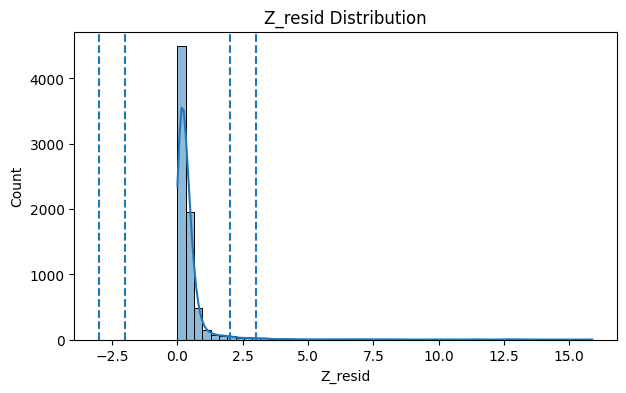

In [92]:
plt.figure(figsize=(7,4))
sns.histplot(df["Z_resid"], bins=50, kde=True)
plt.axvline(2, linestyle="--")
plt.axvline(-2, linestyle="--")
plt.axvline(3, linestyle="--")
plt.axvline(-3, linestyle="--")
plt.title("Z_resid Distribution")
plt.show()


In [94]:
df_clean = df[np.abs(df["Z_resid"]) <= 2].copy()


In [95]:
from scipy import stats

x_c = df_clean["dis_R"].values
y_c = df_clean["dis_l (wlm)"].values

slope_c, intercept_c, r_c, p_c, std_c = stats.linregress(x_c, y_c)
y_hat_c = slope_c * x_c + intercept_c
r2_c = r_c**2

print("Clean slope:", slope_c)
print("Clean intercept:", intercept_c)
print("Clean R²:", r2_c)


Clean slope: 1.004626298233677
Clean intercept: -1.7183110580922403
Clean R²: 0.9781676282869668


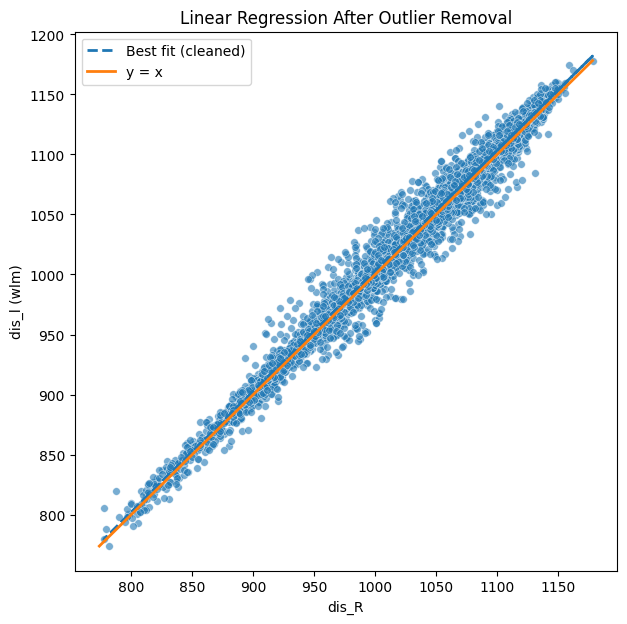

In [96]:
plt.figure(figsize=(7,7))

# Clean points
sns.scatterplot(data=df_clean, x="dis_R", y="dis_l (wlm)", alpha=0.6, s=30)

# Best fit line
plt.plot(x_c, y_hat_c, linestyle='--', linewidth=2, label="Best fit (cleaned)")

# Identity line
min_v = min(x_c.min(), y_c.min())
max_v = max(x_c.max(), y_c.max())
plt.plot([min_v, max_v], [min_v, max_v], linewidth=2, label="y = x")

plt.xlabel("dis_R")
plt.ylabel("dis_l (wlm)")
plt.title("Linear Regression After Outlier Removal")
plt.legend()
plt.show()


In [ ]:
%pip install plotly ipywidgets``


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# import pandas as pd
# import numpy as np
# import plotly.graph_objects as go
# from ipywidgets import Checkbox, VBox, Output, interactive



In [50]:
filtered=df[df["Possible reason"]!= 'MISSING RIGHT WING'].copy()
filtered1=filtered[filtered["Possible reason"]!='DAMAGED RIGHT WING'].copy()

In [52]:
filtered1

,n,vpn,cd,cm,cy,md,g,s,c,wlmm,...,Ml_cal,Residual,|R|,R^2,Possible reason,Notes,Unnamed: 81,vpn.1,AbsResidual,Z_resid
0,1,22077901,1,August,96,Odour-baited trap,Gp,2,2.0,7.61,...,7.474337,9.350483,0.135663,0.018404,NO DAMAGE TO RIGHT WING,NaN,NaN,22077901,9.350483,0.402130
1,2,22077902,1,August,96,Odour-baited trap,Gp,2,1.0,7.61,...,7.437755,9.696553,0.172245,0.029668,NO DAMAGE TO RIGHT WING,NaN,NaN,22077902,9.696553,0.417014
2,3,22077903,1,August,96,Odour-baited trap,Gp,2,7.0,7.32,...,7.231330,-4.622743,0.088670,0.007862,NO DAMAGE TO RIGHT WING,NaN,NaN,22077903,4.622743,-0.198807
3,4,22077904,1,August,96,Odour-baited trap,Gp,2,7.0,7.23,...,7.193514,1.304658,0.036486,0.001331,NO DAMAGE TO RIGHT WING,NaN,NaN,22077904,1.304658,0.056109
4,5,22077905,1,August,96,Odour-baited trap,Gp,2,1.0,7.71,...,7.600226,0.348339,0.109774,0.012050,NO DAMAGE TO RIGHT WING,NaN,NaN,22077905,0.348339,0.014981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7431,7439,22115516,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,6.841446,-2.515671,0.098554,0.009713,NO DAMAGE TO RIGHT WING,NaN,NaN,22115516,2.515671,-0.108190
7432,7440,22115517,24,February,97,Odour-baited trap,Gp,1,NaN,6.94,...,6.860903,6.140454,0.079097,0.006256,NO DAMAGE TO RIGHT WING,NaN,NaN,22115517,6.140454,0.264079
7433,7441,22115518,24,February,97,Odour-baited trap,Gp,1,NaN,6.84,...,6.849781,1.200731,0.009781,0.000096,NO DAMAGE TO RIGHT WING,NaN,NaN,22115518,1.200731,0.051639
7434,7442,22115519,24,February,97,Odour-baited trap,Gp,2,6.0,6.75,...,6.700864,9.424230,0.049136,0.002414,NO DAMAGE TO RIGHT WING,NaN,NaN,22115519,9.424230,0.405302


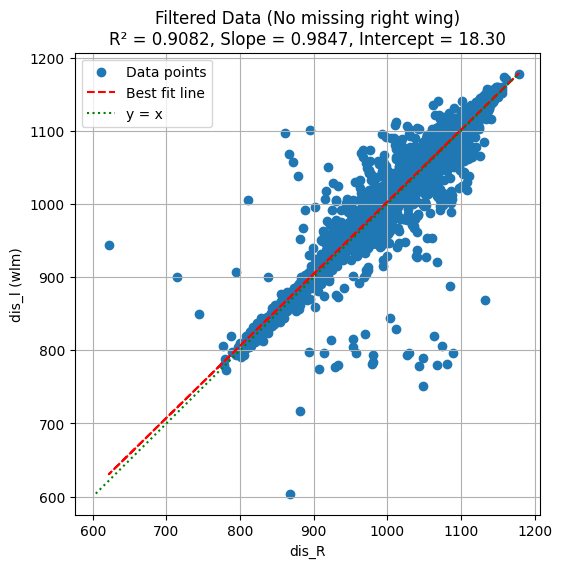

In [54]:
x = filtered["dis_R"]
y = filtered["dis_l (wlm)"]

# Linear regression
slope, intercept = np.polyfit(x, y, 1)
y_fit = slope * x + intercept
r_squared = np.corrcoef(x, y)[0,1]**2

# Plot
plt.figure(figsize=(6,6))
plt.scatter(x, y, label="Data points")

# Regression line
plt.plot(x, y_fit, 'r--', label="Best fit line")

# Perfect agreement line y=x
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], 'g:', label="y = x")

plt.xlabel("dis_R")
plt.ylabel("dis_l (wlm)")
plt.title(f"Filtered Data (No missing right wing)\nR² = {r_squared:.4f}, Slope = {slope:.4f}, Intercept = {intercept:.2f}")
plt.legend()
plt.grid(True)
plt.show()